In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
#After importing the required libraries for data visualization and preprocessing. We load our dataset

In [ ]:
dataset = pd.read_csv('/content/Loan_Approval_Reject.csv')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            2000 non-null   object
 1   City            2000 non-null   object
 2   Income          2000 non-null   int64 
 3   Credit-Score    2000 non-null   int64 
 4   Loan_amount     2000 non-null   int64 
 5   Years_Employed  2000 non-null   int64 
 6   Points          2000 non-null   int64 
 7   Loan_Approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [ ]:
dataset.describe()

,Income,Credit-Score,Loan_amount,Years_Employed,Points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [ ]:
dataset.describe(include='all')

,Name,City,Income,Credit-Score,Loan_amount,Years_Employed,Points,Loan_Approved
count,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000
unique,2000,1882,NaN,NaN,NaN,NaN,NaN,2
top,Nicholas Cunningham,North Joseph,NaN,NaN,NaN,NaN,NaN,False
freq,1,4,NaN,NaN,NaN,NaN,NaN,1121
mean,NaN,NaN,90585.977000,573.946000,25308.503000,20.441000,56.680000,NaN
std,NaN,NaN,34487.874907,160.564945,14207.320147,11.777813,18.638033,NaN
min,NaN,NaN,30053.000000,300.000000,1022.000000,0.000000,10.000000,NaN
25%,NaN,NaN,61296.250000,433.000000,12748.750000,10.000000,45.000000,NaN
50%,NaN,NaN,90387.500000,576.000000,25661.500000,21.000000,55.000000,NaN
75%,NaN,NaN,120099.750000,715.000000,37380.500000,31.000000,70.000000,NaN


In [ ]:
dataset.shape

(2000, 8)

In [ ]:
#Firstly we split our dataset into input & output.(Numerical Values only). Thereafter, we further slipt the dataset into,
#trainning data & testing data with the train_test_split function from sklearn.

In [ ]:
X = dataset.iloc[:, 2:7].values

y = dataset['Loan_Approved'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)



print('X_train_shape:' + str(X_train.shape))
print('X_test_shape:' + str(X_test.shape))
print('y_train_shape:' + str(y_train.shape))
print('y_test_shape:' + str(y_test.shape))

X_train_shape:(1600, 5)
X_test_shape:(400, 5)
y_train_shape:(1600,)
y_test_shape:(400,)


In [ ]:


from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_train_s = Scaler.fit_transform(X_train)

X_test_s = Scaler.transform(X_test)

print(X_train_s)
print(X_test_s)


[[ 1.02860223  0.37581346  0.20429149 -0.72514954  0.72167273]
 [-0.13729998  0.14438246 -0.25515669 -0.46932727  0.18210433]
 [-1.53925139 -1.41934056 -1.68172361 -1.0662459  -1.16681666]
 ...
 [ 0.95899872 -1.55694819 -1.48447582 -0.55460136  0.18210433]
 [ 1.1253285  -0.9940079  -1.44173645  1.23615452  0.18210433]
 [-0.84327427  1.4516549  -0.67249816  0.63923589  1.26124113]]
[[-0.7130792   0.7385972  -1.1128964  -0.98097181  0.45188853]
 [ 1.66245199  0.63851893  0.95567484 -0.46932727  0.99145693]
 [-1.22122537  1.09512605 -0.58062259 -0.72514954  0.45188853]
 ...
 [-0.11672609 -0.57493013  0.08978092  1.49197679 -0.62724826]
 [-0.93663918 -1.57571286 -1.49326269  0.04231727 -0.35746406]
 [-0.44272087 -0.78759646  1.11587717 -0.38405318 -0.89703246]]


In [ ]:
#BUILDING THE NETWORK: We are now ready to build our network.
#We do this with the Keras Sequential model which allows us to build our neural network layer by layer.
# When adding layer we need to specify what type of layer we are adding.
#In a simple feedforward network, we use a ‘Dense’ layer,
#which means each neuron in the layer is connected to each neuron in the previous layer

In [ ]:
from tensorflow import keras

model = tf.keras.Sequential([
    tf.keras.Input(shape=(5,)),
    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85 (340.00 B)

 Trainable params: 85 (340.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# After building the model structure in Keras,we need to compile the model,
# via compile() method of keras.  In this regard, we set the choice of optimizer, loss function,
# and metrics to be computed.

model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])





In [ ]:
# FITTING. After our model have been compiled, training the model is performed
#by calling the fit() method from keras.Model class.

import time
my_callbacks=[keras.callbacks.EarlyStopping(
              monitor = "val_accuracy",
              patience = 5),

            keras.callbacks.ModelCheckpoint(
              filepath = "model/best_model.keras",
              monitor = "val_loss",
              save_best_only = True,
              verbose=2)]

start = time.time()
history = model.fit(x=X_train_s, y=y_train,
                    batch_size = 32,
                    epochs = 50,
                    validation_split = 0.2,
                    callbacks = my_callbacks)
end = time.time()
training_duration = end - start

print("training duration = {:.3f}".format(training_duration))



Epoch 1/50
26/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5702 - loss: 0.6914   
Epoch 1: val_loss improved from inf to 0.60849, saving model to model/best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5864 - loss: 0.6774 - val_accuracy: 0.6500 - val_loss: 0.6085
Epoch 2/50
27/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7051 - loss: 0.5794 
Epoch 2: val_loss improved from 0.60849 to 0.53232, saving model to model/best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7182 - loss: 0.5731 - val_accuracy: 0.7719 - val_loss: 0.5323
Epoch 3/50
25/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4967 
Epoch 3: val_loss improved from 0.53232 to 0.46740, saving model to model/best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8110 - loss: 0.4938 - val_accuracy: 0.8406 - val_loss: 0.4674
Epoch 4/50
26/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8888 - loss: 0.4166 
Epoch 4: val_loss improved from 0.46740 to 

In [ ]:
#Once the training has been completed, we can plot the training and validation accuracy using the below code.

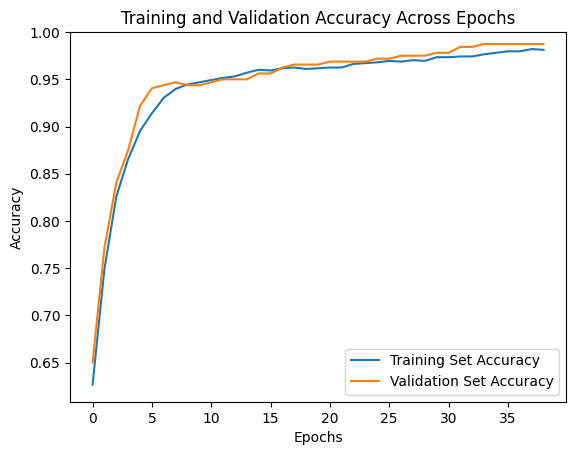

In [ ]:
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
plt.plot(accuracy, label='Training Set Accuracy')
plt.plot(validation_accuracy, label='Validation Set Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy Across Epochs')
plt.legend()

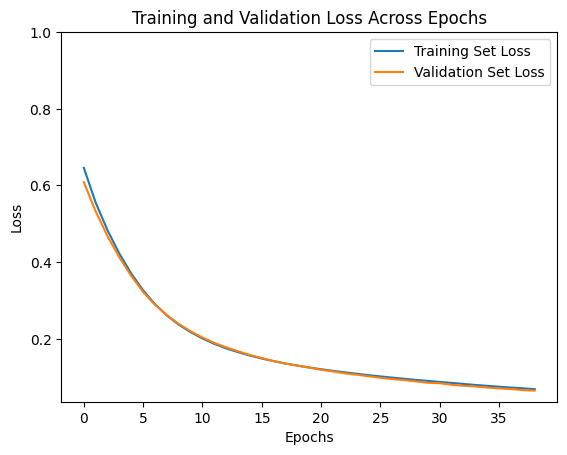

In [ ]:
loss = history.history['loss']
validation_loss = history.history['val_loss']
plt.plot(loss, label='Training Set Loss')
plt.plot(validation_loss, label='Validation Set Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Loss Across Epochs')
plt.legend()

In [ ]:
#To evaluate the performance of model, you can use the following code:
from sklearn import metrics
y_pred_prob = model.predict(X_test_s)
y_pred = (y_pred_prob > 0.5).astype(int)
acc=metrics.accuracy_score(y_test,y_pred)
print('accuracy:%.2f\n\n'%(acc))
cm=metrics.confusion_matrix(y_test,y_pred)
print('Confusion, Matrix:')
print(cm,'n\n')
print('........................................')
result=metrics.classification_report(y_test,y_pred)
print('Classification Report:\n')
print(result)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
accuracy:0.98


Confusion, Matrix:
[[222   2]
 [  4 172]] n

........................................
Classification Report:

              precision    recall  f1-score   support

       False       0.98      0.99      0.99       224
        True       0.99      0.98      0.98       176

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


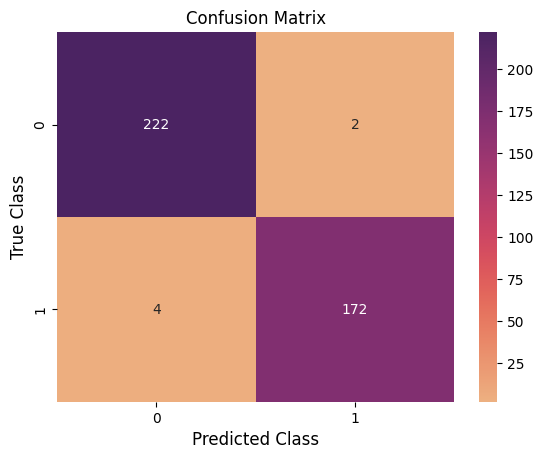

In [ ]:
#MODEL EVALUATION: Now we have trained our neural network we want to review the accuracy and
#validation metrics and also see how this network performs when making predictions for the test
# data which we held back.

from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test_s)

y_pred = (y_pred_prob > 0.5).astype(int)

Confusion_matrix = confusion_matrix(y_test,y_pred)

ax = sns.heatmap(Confusion_matrix, cmap='flare', annot=True,
                 fmt='d')

plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title('Confusion Matrix', fontsize=12)
plt.show()

